## Final Project DATASCI 151: Lucas An, Tiana Lee, Minjun Jang

### Do counties that strongly support a presidential candidate vote similarly in Senate races?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pres_county = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
pres_candidate = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
senate_county = pd.read_csv("4-US_Election_2020/senate_county.csv")
senate_candidate = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

print("President county:", pres_county.shape)
print("President candidate:", pres_candidate.shape)
print("Senate county:", senate_county.shape)
print("Senate candidate:", senate_candidate.shape)

display(pres_county.head())
display(pres_candidate.head())
display(senate_county.head())
display(senate_candidate.head())

#printing and checking data importation

President county: (32177, 6)
President candidate: (32177, 6)
Senate county: (3582, 5)
Senate candidate: (14125, 5)


,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


,state,county,current_votes,total_votes,percent
0,Delaware,Kent County,84975,87025,100
1,Delaware,New Castle County,279462,287633,100
2,Delaware,Sussex County,126498,129352,100
3,Georgia,Appling County,8187,8341,100
4,Georgia,Atkinson County,3097,3155,100


,state,county,candidate,party,total_votes
0,Delaware,Kent County,Lauren Witzke,REP,38571
1,Delaware,Kent County,Mark Turley,IPD,1553
2,Delaware,Kent County,Nadine Frost,LIB,958
3,Delaware,New Castle County,Lauren Witzke,REP,80081
4,Delaware,New Castle County,Mark Turley,IPD,4277


The datasets 'president_county_candidate.csv' and 'senate_county_candidate.csv' were used to build a county level comparison dataset. Both datasets were filtered to include only Democratic and Republican candidates so that vote shares could be compared across elections. The data were grouped by state, county, and party to calculate total votes for each major party within each county.

After grouping, Democratic and Republican vote totals from the presidential and Senate elections were merged into a single dataset called 'merged'. Each row in this dataset represents one county and includes presidential Democratic and Republican votes, Senate Democratic, and Republican votes, total two party votes, and Democratic vote share for each election. This merged dataset allows direct comparison of how counties voted across the two races.

In [3]:
pres_major = pres_candidate.query("party == 'DEM' or party == 'REP'")

pres_grouped = pres_major.groupby(by = ["state", "county", "party"]).agg(
    votes = ("total_votes", "sum")
).reset_index()

pres_dem = pres_grouped.query("party == 'DEM'")[["state", "county", "votes"]].rename(
    columns = {"votes": "pres_dem_votes"}
)

pres_rep = pres_grouped.query("party == 'REP'")[["state", "county", "votes"]].rename(
    columns = {"votes": "pres_rep_votes"}
)

senate_dem = senate_candidate.query("party == 'DEM'").groupby(by = ["state", "county"]).agg(
    senate_dem_votes = ("total_votes", "sum")
).reset_index()

senate_total = senate_county[["state", "county", "total_votes"]].rename(
    columns = {"total_votes": "senate_total_votes"}
)

merged = pd.merge(left = pres_dem, right = pres_rep, on = ["state", "county"], how = "inner")
merged = pd.merge(left = merged, right = senate_dem, on = ["state", "county"], how = "inner")
merged = pd.merge(left = merged, right = senate_total, on = ["state", "county"], how = "inner")

merged["pres_total_major"] = merged["pres_dem_votes"] + merged["pres_rep_votes"]

merged["pres_dem_share"] = merged["pres_dem_votes"] / merged["pres_total_major"]
merged["senate_dem_share"] = merged["senate_dem_votes"] / merged["senate_total_votes"]
merged = merged.query(
    "0 <= pres_dem_share <= 1 and 0 <= senate_dem_share <= 1"
)
#hey y'all this removes the extremeties we were seeing on the graph

merged["share_difference"] = merged["pres_dem_share"] - merged["senate_dem_share"]

display(merged.head())
print(merged.shape)


#purpose is to build one county level comparison comparing democratic voting patterns between pres and senate elec

,state,county,pres_dem_votes,pres_rep_votes,senate_dem_votes,senate_total_votes,pres_total_major,pres_dem_share,senate_dem_share,share_difference
0,Alabama,Autauga County,7503,19838,8277,27770,27341,0.274423,0.298055,-0.023632
1,Alabama,Baldwin County,24578,83544,28925,109679,108122,0.227317,0.263724,-0.036407
2,Alabama,Barbour County,4816,5622,5021,10518,10438,0.461391,0.477372,-0.015981
3,Alabama,Bibb County,1986,7525,2244,9595,9511,0.208811,0.233872,-0.025061
4,Alabama,Blount County,2640,24711,3290,27588,27351,0.096523,0.119255,-0.022732


(2618, 10)


## Dataset Overview

The merged dataset contains county level voting information from the 2020 presidential and Senate elections. Each row represents a county, while columns include Democratic and Republican total votes, total major party votes, Democratic vote shares, and the difference between presidential and Senate Democratic support. This dataset will be used to examine how closely counties voted across the two elections and identify places where voting patterns shifted

In [4]:
print("Rows, Columns:", merged.shape)

display(merged.head())

display(merged[[
    "pres_dem_share",
    "senate_dem_share",
    "share_difference"
]].describe().round(3))


#quizk overview of final merged dataset

Rows, Columns: (2618, 10)


,state,county,pres_dem_votes,pres_rep_votes,senate_dem_votes,senate_total_votes,pres_total_major,pres_dem_share,senate_dem_share,share_difference
0,Alabama,Autauga County,7503,19838,8277,27770,27341,0.274423,0.298055,-0.023632
1,Alabama,Baldwin County,24578,83544,28925,109679,108122,0.227317,0.263724,-0.036407
2,Alabama,Barbour County,4816,5622,5021,10518,10438,0.461391,0.477372,-0.015981
3,Alabama,Bibb County,1986,7525,2244,9595,9511,0.208811,0.233872,-0.025061
4,Alabama,Blount County,2640,24711,3290,27588,27351,0.096523,0.119255,-0.022732


,pres_dem_share,senate_dem_share,share_difference
count,2618.000,2618.000,2618.000
mean,0.313,0.306,0.006
std,0.126,0.136,0.118
min,0.000,0.000,-0.665
25%,0.212,0.204,-0.022
50%,0.303,0.292,0.007
75%,0.403,0.388,0.041
max,1.000,0.964,0.810


## Comparing Presidential and Senate Voting Patterns

To examine whether counties voted similarly across the presidential and Senate elections, we compare Democratic vote share in both races. If counties fall close to a straight diagonal pattern, it suggests voting behavior was consistent across elections. Counties far from that pattern indicate stronger support for one party in one race versus the other.

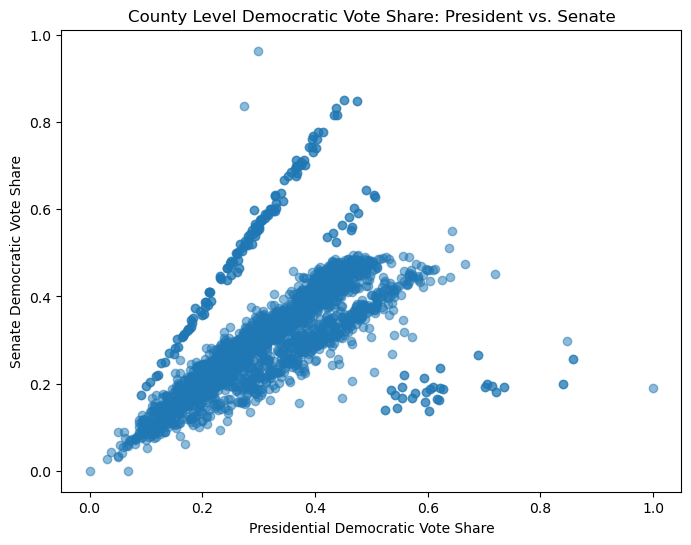

Correlation: 0.596


In [5]:
plt.figure(figsize = (8, 6))

plt.scatter(
    merged["pres_dem_share"],
    merged["senate_dem_share"],
    alpha = 0.5
)

plt.xlabel("Presidential Democratic Vote Share")
plt.ylabel("Senate Democratic Vote Share")
plt.title("County Level Democratic Vote Share: President vs. Senate")
plt.show()

correlation = merged["pres_dem_share"].corr(merged["senate_dem_share"])
print("Correlation:", round(correlation, 3))


#creating County Level Democratic Vote Share Pres vs. Senate scatter plot and calculating corr




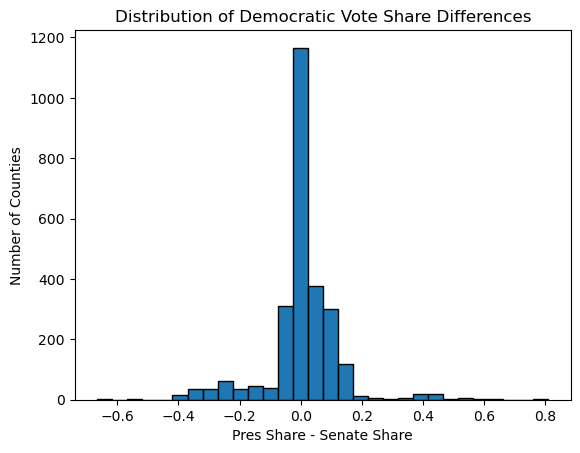

In [6]:
merged.sort_values(by = "share_difference").head(10)
merged.sort_values(by = "share_difference", ascending = False).head(10)

plt.hist(merged["share_difference"], bins = 30, edgecolor = "black")
plt.xlabel("Pres Share - Senate Share")
plt.ylabel("Number of Counties")
plt.title("Distribution of Democratic Vote Share Differences")
plt.show()

#finds counties with largest diff, creates hist of vote share diff

scatterplot shows a moderate positive relationship between presidential and senate democratic vote share across counties. Counties that voted more Democratic in the presidential race generally also voted more Democratic in the senate race. However, differences around the trend suggest that some counties voted differently between the presidential and senate races.

In [7]:
state_summary = merged.groupby("state").agg(
    avg_pres_share = ("pres_dem_share", "mean"),
    avg_senate_share = ("senate_dem_share", "mean"),
    avg_difference = ("share_difference", "mean")
)

display(state_summary.sort_values(by = "avg_difference"))

#move from county level to state level, avg dem pres vote share, avg dem senate vote share, and avg diff between the two elec



,avg_pres_share,avg_senate_share,avg_difference
state,,,
Georgia,0.353932,0.467957,-0.114025
Rhode Island,0.429669,0.469675,-0.040006
Montana,0.245749,0.282465,-0.036716
New Hampshire,0.400769,0.435113,-0.034344
Illinois,0.296723,0.327179,-0.030456
Virginia,0.326572,0.354666,-0.028094
Mississippi,0.307442,0.335012,-0.027570
Alabama,0.265406,0.292054,-0.026648
Kentucky,0.240813,0.266716,-0.025902


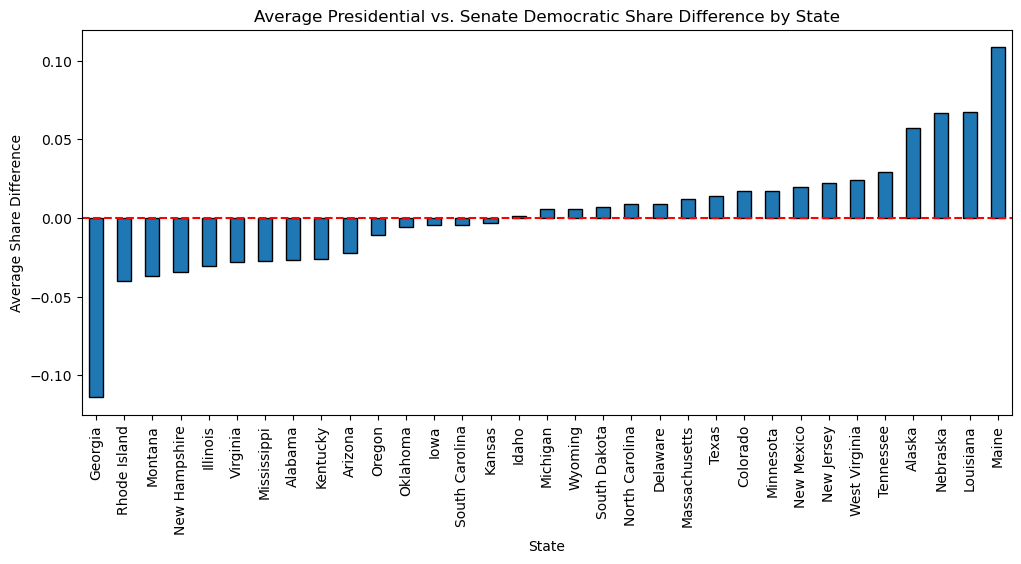

In [8]:
state_summary = state_summary.sort_values(by = "avg_difference")

state_summary["avg_difference"].plot(
    kind = "bar",
    figsize = (12, 5),
    edgecolor = "black"
)

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("State")
plt.ylabel("Average Share Difference")
plt.title("Average Presidential vs. Senate Democratic Share Difference by State")

plt.show()

#vis state level results from state_summary, neg = senate dems performed better, pos = pres dems performed better

In [10]:
def classified_difference(value):
    if value > 0.05:
        return "Presidential Stronger"
    elif value < -0.05:
        return "Senate Stronger"
    else:
        return "Similar Voting in both races"

merged["difference_category"] = merged["share_difference"].apply(classified_difference)

display(merged["difference_category"].value_counts())


difference_category
Similar Voting in both races    1695
Presidential Stronger            601
Senate Stronger                  322
Name: count, dtype: int64

### State Level Differences in Democratic Vote 

bar chart shows the average difference between presidential and senate Democratic vote share for each state. Negative values indicate that Senate Democratic candidates performed better than Presidential Democratic candidates on average across counties, while positive values indicate stronger Presidential Democratic performance. Most states cluster near zero, suggesting similar voting patterns between races. Some show larger differences, showing that voters somwetimes chose differently between presidential and senate races depending on the state. 

## Discussion and Conclusion

Our goal in this project was to examine whether Democratic vote share in the 2020 presidential election was related to Democratic vote share in the senate elections at the county level. After merging county level election datasets and calculating vote share variables, a slightly positive relationship was found between presidential and senate Democratic performance. Counties that voted more Democratic in the presidential race tended to also vote more Democratic in senate races.

The scatterplot and our found correlation coefficient of 0.596 suggest that there is a relationship, though imperfect, meaning that counties didn't vote identically across elections. The histogram made of vote share differences showed that most counties clustered near small differences, although some displayed stronger senate or presidential performance. State level averages showed that some states had repeated differences between races, suggesting that perhaps political behavior varies geographically.

A lot of our time was spent cleaning and validating the merged dataset. At first, early aggregation methods gave us a graph that was obviously wrong, with strange clusters spread across the graph. These methods produced unrealistic vote shares due to duplicate senate candidate totals. After fixing the duplicate problem and filtering invalid observations, the results became much more interpretable and realistic. 
